Simple MultiAI Agent Architecture

In [28]:
import os
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langchain.chat_models import init_chat_model

In [29]:
from dotenv import load_dotenv
load_dotenv()

os.environ['GROQ_API_KRY'] = os.getenv("GROQ_API_KEY")

In [30]:
## Define the state
class AgentState(MessagesState):
    next_agent: str

In [31]:
## Create Tools
@tool
def search_web(query: str) -> str:
    """Search the web for information."""

    ## Using Tavily for the web search
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)

@tool
def write_summary(content: str) -> str:
    """Write the summary for the provided content."""

    ## Simple summary generation
    summary = f"Summary for finding: \n\n{content[:500]}"
    return summary

In [32]:
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000021FFEB28910>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000021FFEB2A990>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [33]:
## Define agent functions
def researcher_agent(state: AgentState):
    """Researcher agent the searchers for information."""

    messages = state["messages"]

    ## Add system messages for context
    system_msg = SystemMessage(content="You are a search assistant. use the search_web to find information about the user's request.")

    ## Call LLM with tools
    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)

    ## Retrun the response and route to write
    return {
        "messages": [response],
        "next_agent": "writer"
    }

In [34]:
def write_agent(state: AgentState):
    """Write agent the creates summaries."""

    messages = state["messages"]

    ## Add system messages
    system_msg = SystemMessage(content="You are a technical writer, Review the conversation and create a clear, concise summary for the findings.")

    ## Simple complition without tools
    response = llm.invoke([system_msg] + messages)

    return {
        "messages": [response],
        "next_agent": "end"
    }

In [35]:
## Tool executor node
def execute_node(state: AgentState):
    """Execute any pending tool calls"""

    messages = state["messages"]
    last_message = messages[-1]

    ## Check if there are tool calls to execute
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        ## Create tool node and execute
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        return response

    ## No tools to execute
    return state

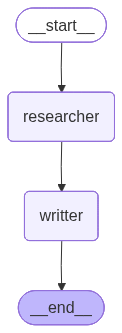

In [36]:
## Build Graph
workflow = StateGraph(MessagesState)

## Add Nodes
workflow.add_node("researcher", researcher_agent)
workflow.add_node("writter", write_agent)

## Define Flow
workflow.set_entry_point("researcher")
workflow.add_edge("researcher", "writter")
workflow.add_edge("writter", END)

final_workflow = workflow.compile()
final_workflow

In [37]:
response = final_workflow.invoke({"messages": "Research about the Agentic AI in the business"})
response["messages"][-1].content

" \n\nBased on the search results, here's a summary of the findings on Agentic AI in business:\n\n**Agentic AI Definition:**\n\nAgentic AI refers to a type of artificial intelligence that is designed to act on behalf of a user or organization, making decisions and taking actions autonomously. Agentic AI systems are programmed to understand their goals, constraints, and environment, and to adapt to new situations and learn from experience.\n\n**Key Characteristics:**\n\n1. **Autonomy:** Agentic AI systems are designed to operate independently, making decisions and taking actions without human intervention.\n2. **Goal-oriented:** Agentic AI systems are programmed to achieve specific goals, which can be defined by the user or organization.\n3. **Adaptability:** Agentic AI systems can adapt to new situations and learn from experience, allowing them to improve their performance over time.\n4. **Contextual understanding:** Agentic AI systems can understand the context in which they are opera